# به نام خدا

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
tips_df = sns.load_dataset('tips')

In [63]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [64]:
# مشخصات
tips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# Handling Missing Values

In [65]:
# check for missing values
tips_df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

# Exploratory Data Analysis (EDA)

<Axes: xlabel='tip', ylabel='Count'>

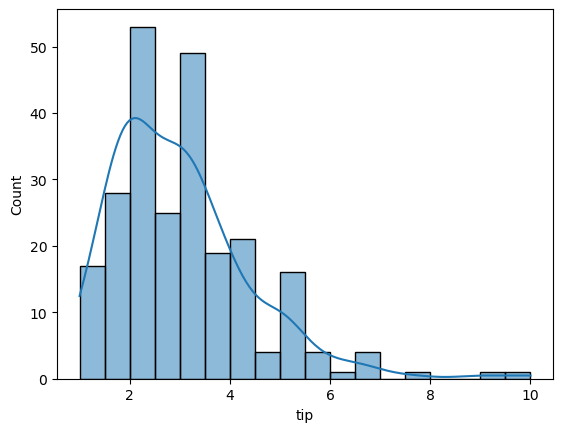

In [66]:
# Distribution of tip amounts
sns.histplot(tips_df['tip'], kde=True)

<div dir='rtl'>

**مشاهدات:**
- بیشتر افراد 1.5 تا 4 دلار انعام دادند
- توزیع Right-skewed یا Positively Skewed

Text(0.5, 1.0, 'Total_bill vs Tip')

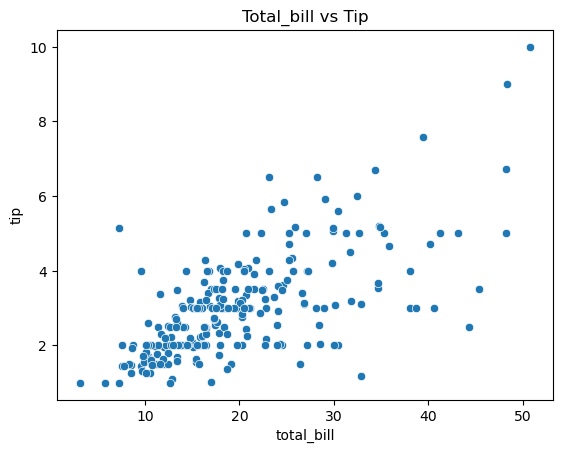

In [67]:
sns.scatterplot(x='total_bill', y='tip', data=tips_df)
plt.title('Total_bill vs Tip')

<div dir='rtl'>

**مشاهدات:**

- یک رابطه **خطی مثبت** بین صورتحساب و انعام دیده می‌شود: با افزایش صورتحساب، انعام هم به‌طور کلی افزایش می‌یابد.
- اما نقاط به‌طور کامل روی یک خط قرار ندارند؛ یعنی `total_bill` تنها عامل تعیین‌کننده انعام نیست.

<Axes: xlabel='smoker', ylabel='tip'>

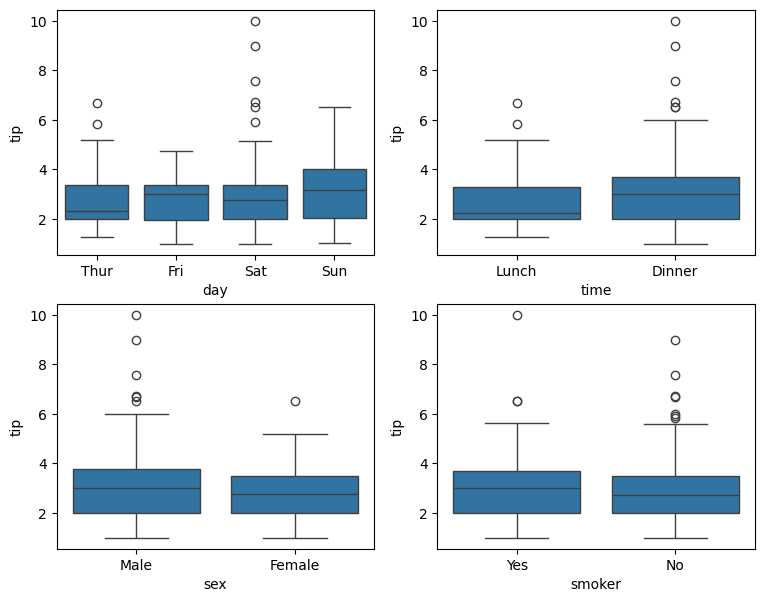

In [68]:
# بررسی تأثیر متغیرهای کیفی بر روی مقدار انعام
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
sns.boxplot(data=tips_df, x='day', y='tip', ax=axes[0, 0])
sns.boxplot(data=tips_df, x='time', y='tip', ax=axes[0, 1])
sns.boxplot(data=tips_df, x='sex', y='tip', ax=axes[1, 0])
sns.boxplot(data=tips_df, x='smoker', y='tip', ax=axes[1, 1])

<div dir='rtl'>

**مشاهدات:**

- **روز هفته:** انعام در روز یکشنبه(sunday) بالاترین میانه را دارد.
- **نوع وعده:** شام (Dinner) انعام بیشتری نسبت به ناهار (Lunch) دارد. پراکندگی در شام هم بیشتر است.
- **سیگاری بودن:** تفاوت معناداری بین سیگاری و غیرسیگاری دیده نمی‌شود. این متغیر احتمالاً تأثیر کمی بر مدل دارد.
- **جنسیت:** تفاوت میانه مرد و زن کم است. احتمالاً این متغیر هم تأثیر قوی‌ای ندارد.

**نتیجه برای مدل‌سازی:**

- متغیرهای `day` و `time` احتمالاً باید در مدل بمانند.
- متغیرهای `smoker` و `sex` ممکن است نامزدهایی برای حذف از مدل باشند.

</div>

# Feature Encoding

In [69]:
# Categorical encoding for 'sex', 'smoker', and 'time'
tips_df['sex'] = tips_df['sex'].cat.codes
tips_df['time'] = tips_df['time'].cat.codes
tips_df['smoker'] = tips_df['smoker'].cat.codes

# One-hot encoding for 'day'
tips_df = pd.get_dummies(tips_df, columns=['day'], prefix='day')
tips_df.head()

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,1,2,False,False,False,True
1,10.34,1.66,0,1,1,3,False,False,False,True
2,21.01,3.50,0,1,1,3,False,False,False,True
3,23.68,3.31,0,1,1,2,False,False,False,True
4,24.59,3.61,1,1,1,4,False,False,False,True


<div dir='rtl'>

⚠️ **نکته مهم:** ما از کدهای دسته‌بندی برای «جنسیت»، «سیگاری» و «زمان» استفاده می‌کنیم زیرا آنها باینری هستند.اما برای «روز»، از کدگذاری one-hot استفاده می‌کنیم تا از ترتیب بین روزها جلوگیری شود.

# Preparing for Modeling

In [70]:
# separate our features and target variable
X = tips_df.drop(columns='tip')
y = tips_df['tip']

print('Feature:', X.columns)
print('Target:', y.name)

Feature: Index(['total_bill', 'sex', 'smoker', 'time', 'size', 'day_Thur', 'day_Fri',
       'day_Sat', 'day_Sun'],
      dtype='object')
Target: tip


# Correlation Analysis

In [76]:
tips_df.corr()['tip'].sort_values(ascending=False)

tip           1.000000
total_bill    0.675734
size          0.489299
day_Sun       0.125114
time          0.121629
day_Sat      -0.002790
smoker       -0.005929
day_Fri      -0.055463
sex          -0.088862
day_Thur     -0.095879
Name: tip, dtype: float64

# Selecting Initial Features

In [ ]:
# انتخاب ویژگی‌های مهم
selected_features = ['total_bill', 'size', 'time','day_Sun']
X_selected = tips_df[selected_features]
X_selected.head()

,total_bill,size,time,day_Sun
0,16.99,2,1,True
1,10.34,3,1,True
2,21.01,3,1,True
3,23.68,2,1,True
4,24.59,4,1,True
